# Comparing Different Search Strategies: Maze

Notes on breaking ties: 

* The order in which the children are explored (see `available directions`) makes a big difference for DFS and dealing with empty spaces. I explore the directions in random order which makes the algorithm stochastic!
* Ties for $h(n)$ and $f(n)$ need to be broken in a consistent manner. I use the most recently added node. To try to keep moving into the same direction.



Helper functions for the Maze Assignment by M. Hahsler
Usage: 
  import maze_helper as mh
  mh.show_some_mazes()
  
Here is an example maze:

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX

The goal is at (np.int64(8), np.int64(1)).
Position(0,0): X
Position(8,1):  


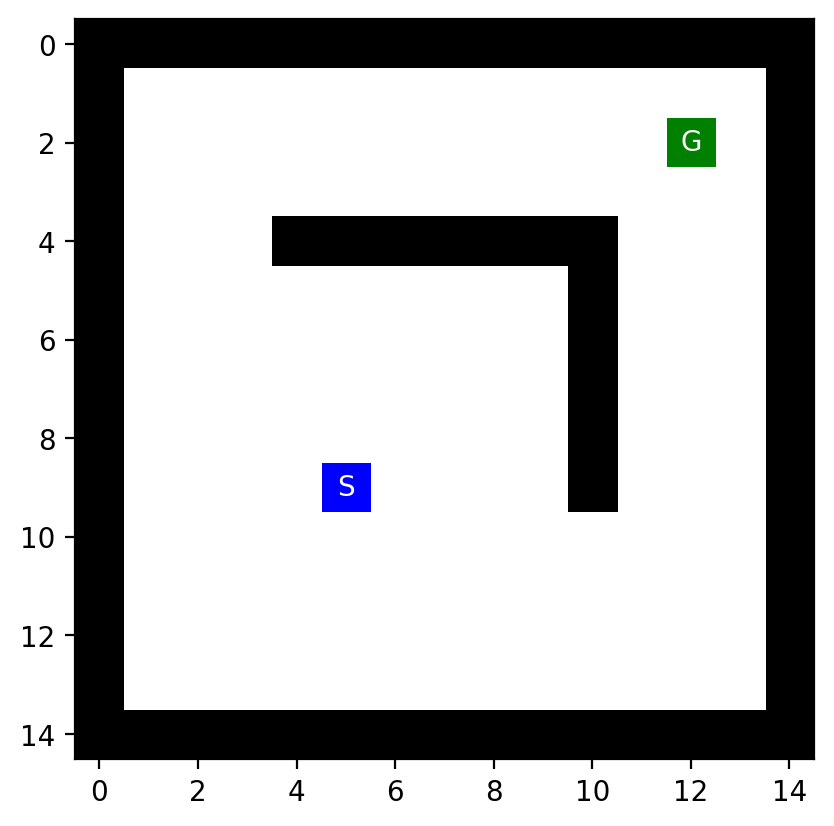

In [1]:
%run maze_helper.py
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np

#f = open("small_maze.txt", "r")
#f = open("medium_maze.txt", "r")
#f = open("large_maze.txt", "r")    # this has only one solution!
#f = open("open_maze.txt", "r")
#f = open("empty_maze.txt", "r")
#f = open("empty_maze_2.txt", "r")
#f = open("loops_maze.txt", "r")
f = open("L_maze.txt", "r")

maze_str = f.read()
maze = parse_maze(maze_str)

# look at two positions in the maze
print("Position(0,0):", maze[0, 0])
print("Position(8,1):", maze[8, 1])

show_maze(maze)

## Implementation

My implementation follows the pseudo code from the slides/textbook.

In [2]:
# tree_search_solution.py has my actual implementation (not published)
import tree_search_solution as ts


# order in which we add new states to the frontier
ts.set_order("NESW")
#ts.set_order(random=True)

## Experiments

### BFS

CPU times: total: 0 ns
Wall time: 998 μs
Path length: 16
Reached squares: 155
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E']


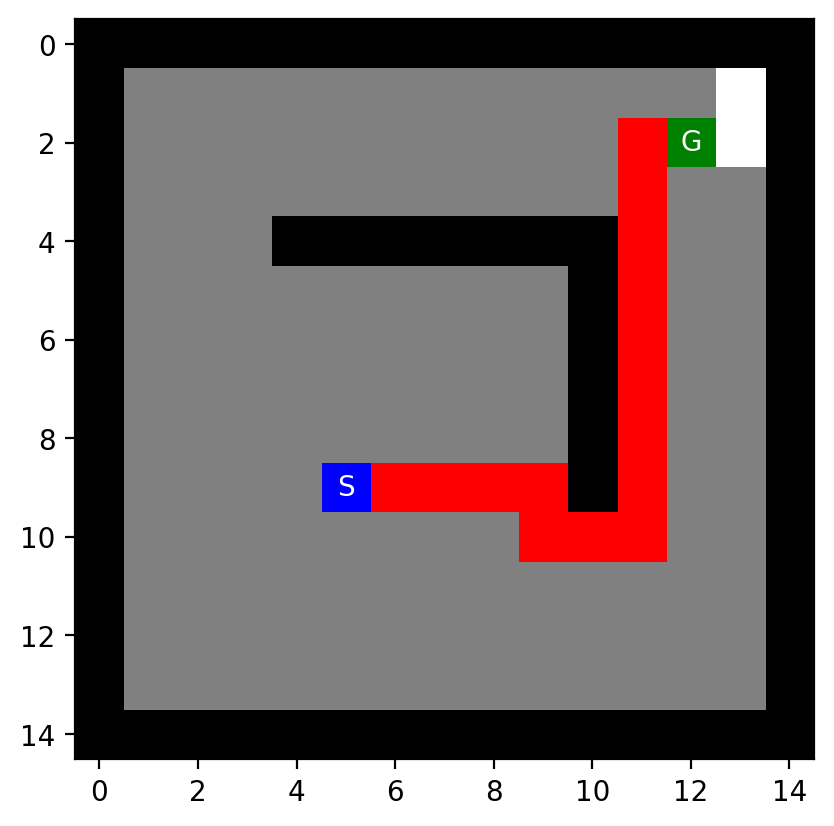

['E',
 'E',
 'E',
 'E',
 'S',
 'E',
 'E',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'E']

In [3]:
ts.set_order("NESW")
#ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "BFS", debug = False, vis = False)
ts.show_path(maze, result)
result['actions']

### DFS 

This implementation uses not reached data structure and has space complexity $O(bm)$ instead of $O(b^m)$ when we reuse the tree search algorithm from BFS!

We need to check for all cycles. If we do not break all cycles correctly, then we will end up in an infinite loop. Here are possible solutions:
* Stop after a fixed number of tries and return no solution `max_tries`.
* IDS solves this problem.

Note on the visualization: I use gray for areas that the algorithm has explored, but DFS has already removed it from memory!

CPU times: total: 0 ns
Wall time: 0 ns
Path length: 50
Reached squares: 75
Action sequence: ['N', 'N', 'N', 'N', 'E', 'E', 'E', 'E', 'S', 'S', 'S', 'S', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E', 'E', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'W', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


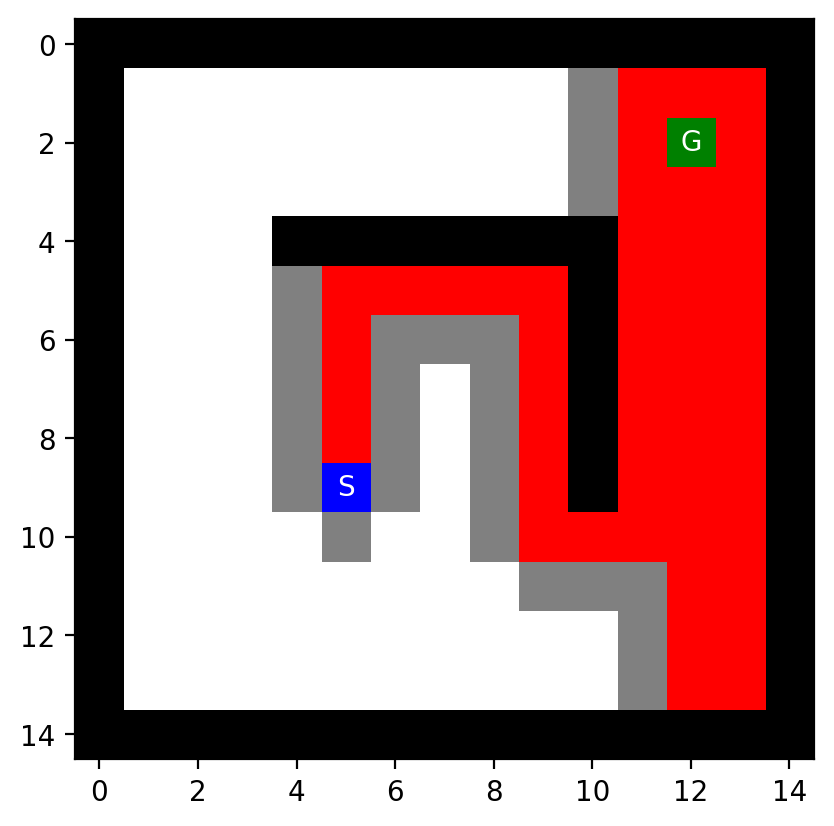

In [4]:
# Note: DFS uses LIFO so the directions come from the stack in reverse order!

# Can get stuck for empty maze since cycle checking is not string enough! 
# I use a maximum number of tries and stop if the goal is not reached.
ts.set_order("NESW")
#ts.set_order("SENW")
#ts.set_order("WSEN")
#ts.set_order(random=True)

%time result = ts.DFS(maze, vis = False, max_tries = 100000, debug_reached = True)

#result
ts.show_path(maze, result)
if result['path'] is None:
    print("No solution found!")

Do the same, but change the order in which we explore states (add them to them as nodes to the frontier).

CPU times: total: 0 ns
Wall time: 997 μs
Path length: 26
Reached squares: 53
Action sequence: ['S', 'S', 'S', 'S', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'W', 'S']


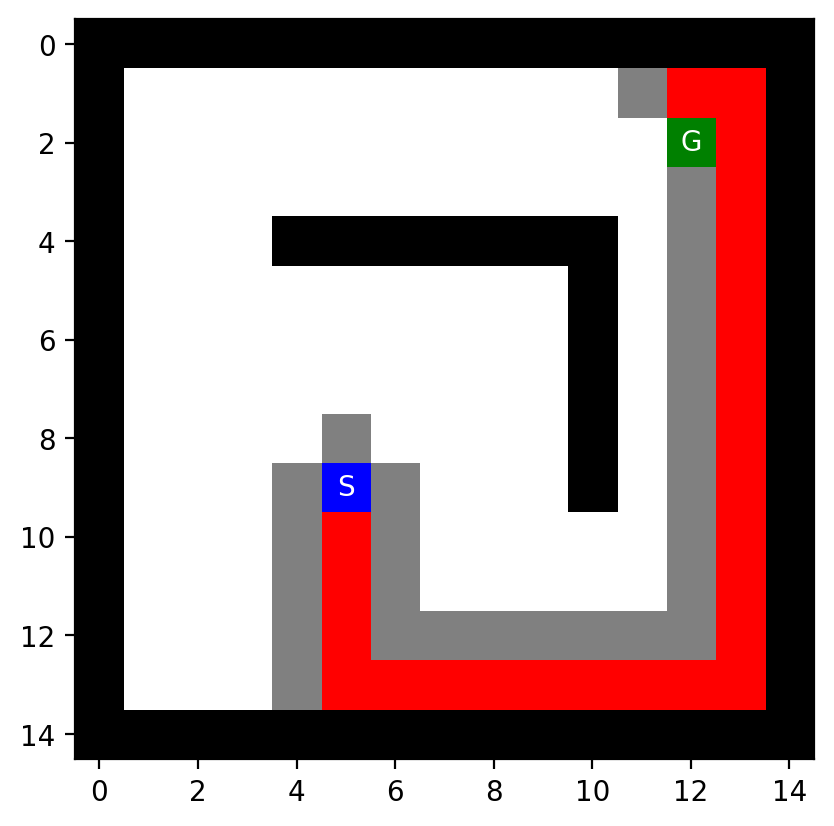

In [5]:
#ts.set_order("NESW")
ts.set_order("SENW")
#ts.set_order("WSEN")
#ts.set_order(random=True)

%time result = ts.DFS(maze, vis = False, max_tries = 100000, debug_reached = True)

#result
ts.show_path(maze, result)
if result['path'] is None:
    print("No solution found!")

We could do a random walk and not check for cycles. This is guaranteed to reach eventually any square including the goal, 
but creates a long path. The path could be simplified leading to the [Tremaux's algorithm](https://en.wikipedia.org/wiki/Maze_solving_algorithm).

CPU times: total: 0 ns
Wall time: 8.62 ms
Path length: 746
Reached squares: 136
Action sequence: ['N', 'W', 'W', 'N', 'N', 'S', 'E', 'N', 'W', 'S', 'S', 'N', 'E', 'N', 'E', 'N', 'S', 'S', 'N', 'E', 'S', 'W', 'W', 'S', 'S', 'E', 'E', 'W', 'N', 'S', 'E', 'E', 'W', 'N', 'W', 'E', 'W', 'E', 'S', 'W', 'E', 'W', 'E', 'E', 'W', 'E', 'N', 'E', 'N', 'W', 'W', 'S', 'E', 'W', 'N', 'E', 'E', 'E', 'S', 'N', 'S', 'S', 'N', 'W', 'S', 'N', 'S', 'N', 'E', 'W', 'N', 'S', 'S', 'W', 'S', 'E', 'S', 'W', 'S', 'E', 'S', 'N', 'N', 'S', 'S', 'W', 'W', 'E', 'E', 'N', 'E', 'N', 'W', 'S', 'N', 'E', 'N', 'N', 'W', 'N', 'E', 'N', 'W', 'W', 'S', 'N', 'W', 'W', 'S', 'N', 'E', 'S', 'E', 'E', 'N', 'N', 'E', 'S', 'S', 'W', 'E', 'S', 'S', 'S', 'W', 'E', 'N', 'S', 'S', 'N', 'N', 'N', 'N', 'N', 'S', 'N', 'W', 'N', 'S', 'S', 'E', 'W', 'N', 'S', 'W', 'W', 'S', 'W', 'N', 'E', 'N', 'E', 'S', 'E', 'E', 'W', 'S', 'E', 'W', 'S', 'E', 'S', 'N', 'E', 'E', 'W', 'E', 'W', 'W', 'W', 'S', 'W', 'E', 'W', 'S', 'W', 'W', 'W', 'S', 'N', 'N

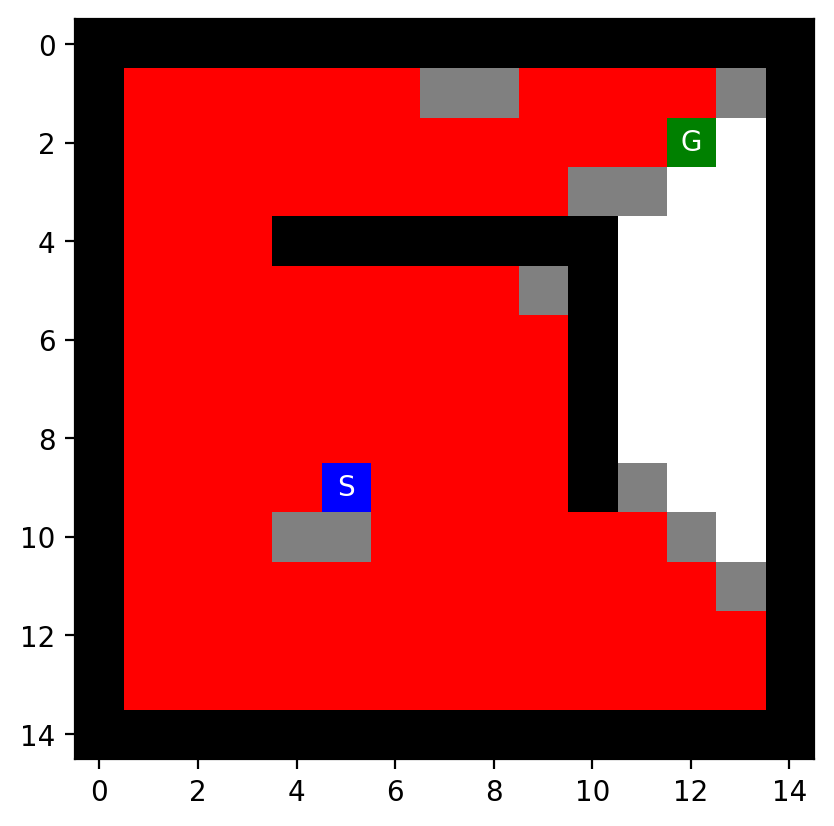

CPU times: total: 0 ns
Wall time: 3.97 ms
Path length: 412
Reached squares: 115
Action sequence: ['E', 'E', 'N', 'W', 'N', 'S', 'S', 'E', 'W', 'E', 'W', 'W', 'E', 'S', 'S', 'S', 'W', 'S', 'E', 'E', 'W', 'W', 'E', 'E', 'E', 'N', 'N', 'N', 'S', 'S', 'W', 'S', 'N', 'N', 'S', 'S', 'W', 'E', 'W', 'E', 'N', 'W', 'S', 'W', 'N', 'N', 'N', 'W', 'E', 'E', 'N', 'S', 'W', 'W', 'S', 'N', 'W', 'N', 'E', 'S', 'E', 'S', 'N', 'W', 'W', 'E', 'N', 'N', 'E', 'W', 'E', 'S', 'E', 'W', 'E', 'E', 'N', 'N', 'S', 'S', 'E', 'W', 'E', 'W', 'E', 'S', 'N', 'S', 'N', 'W', 'N', 'S', 'S', 'W', 'N', 'N', 'W', 'N', 'N', 'E', 'S', 'E', 'E', 'N', 'E', 'N', 'S', 'S', 'N', 'W', 'N', 'S', 'S', 'N', 'E', 'W', 'N', 'S', 'W', 'E', 'N', 'E', 'W', 'S', 'W', 'W', 'E', 'W', 'E', 'E', 'E', 'N', 'W', 'S', 'N', 'W', 'S', 'N', 'W', 'W', 'E', 'S', 'E', 'N', 'S', 'S', 'N', 'N', 'W', 'S', 'W', 'N', 'S', 'S', 'E', 'N', 'W', 'S', 'S', 'S', 'W', 'W', 'S', 'E', 'W', 'S', 'S', 'N', 'E', 'N', 'W', 'N', 'W', 'W', 'S', 'E', 'S', 'N', 'W', 'N', 'S

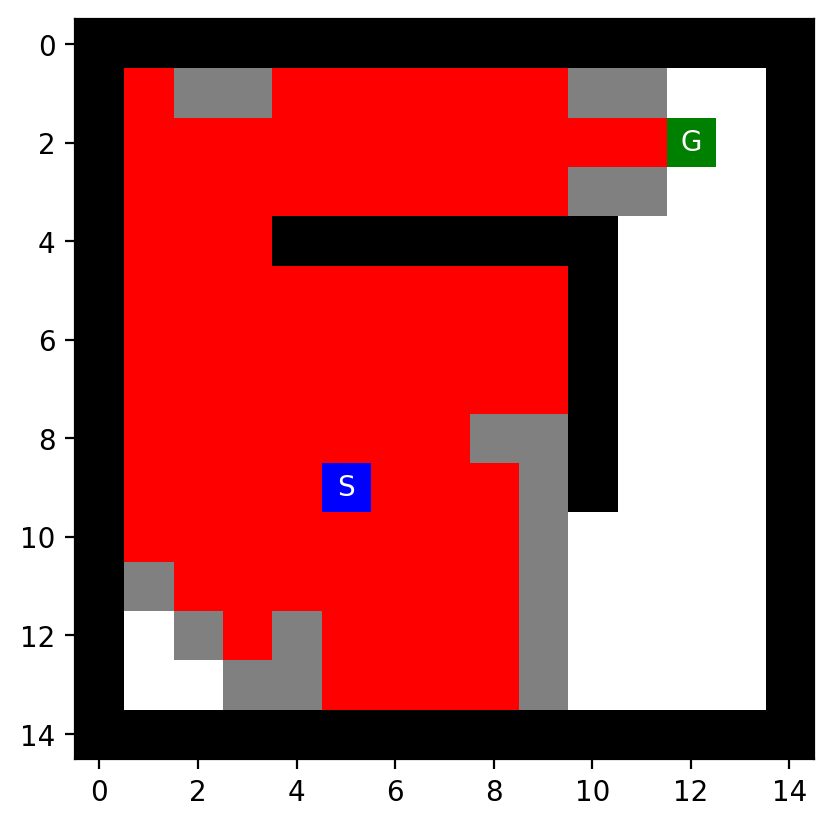

CPU times: total: 0 ns
Wall time: 3.65 ms
Path length: 484
Reached squares: 130
Action sequence: ['E', 'S', 'E', 'W', 'S', 'N', 'W', 'N', 'W', 'S', 'S', 'E', 'N', 'W', 'E', 'S', 'N', 'N', 'N', 'S', 'E', 'W', 'N', 'N', 'W', 'N', 'W', 'E', 'N', 'E', 'W', 'W', 'E', 'S', 'N', 'E', 'E', 'E', 'W', 'E', 'S', 'N', 'E', 'E', 'S', 'N', 'W', 'E', 'W', 'W', 'W', 'E', 'E', 'S', 'N', 'E', 'S', 'W', 'N', 'E', 'W', 'W', 'E', 'E', 'S', 'S', 'S', 'W', 'N', 'E', 'W', 'S', 'E', 'S', 'S', 'W', 'S', 'S', 'S', 'W', 'N', 'W', 'W', 'W', 'E', 'S', 'E', 'N', 'W', 'E', 'N', 'N', 'N', 'W', 'S', 'N', 'W', 'S', 'N', 'S', 'S', 'W', 'E', 'E', 'N', 'S', 'S', 'N', 'S', 'N', 'S', 'W', 'N', 'S', 'N', 'S', 'N', 'N', 'W', 'S', 'W', 'S', 'W', 'N', 'N', 'N', 'S', 'N', 'S', 'N', 'E', 'W', 'N', 'E', 'S', 'W', 'N', 'S', 'N', 'E', 'S', 'W', 'S', 'S', 'E', 'E', 'N', 'S', 'S', 'E', 'E', 'W', 'S', 'N', 'E', 'N', 'S', 'E', 'N', 'S', 'S', 'E', 'E', 'W', 'W', 'W', 'N', 'W', 'W', 'E', 'S', 'N', 'W', 'N', 'S', 'N', 'N', 'N', 'S', 'E', 'S

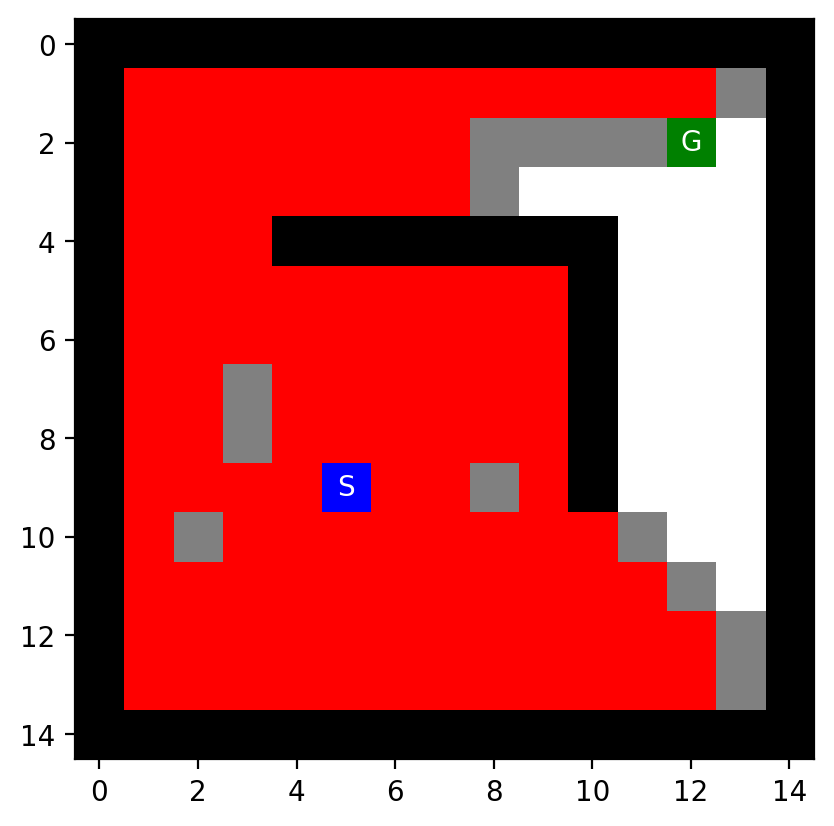

CPU times: total: 0 ns
Wall time: 0 ns
Path length: 44
Reached squares: 52
Action sequence: ['W', 'N', 'E', 'W', 'N', 'S', 'E', 'W', 'S', 'N', 'W', 'N', 'N', 'W', 'N', 'N', 'W', 'S', 'E', 'E', 'N', 'N', 'E', 'E', 'N', 'S', 'W', 'E', 'N', 'S', 'E', 'E', 'E', 'E', 'W', 'E', 'N', 'S', 'N', 'W', 'E', 'E', 'E', 'E']


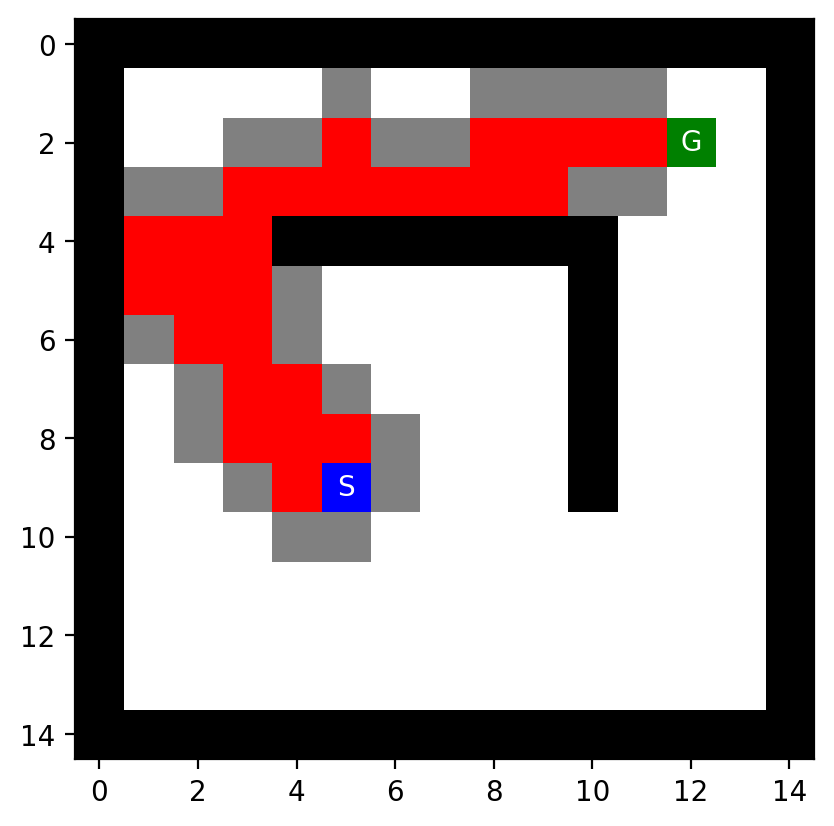

CPU times: total: 0 ns
Wall time: 4.2 ms
Path length: 620
Reached squares: 143
Action sequence: ['N', 'S', 'N', 'W', 'E', 'S', 'S', 'W', 'S', 'W', 'E', 'E', 'N', 'S', 'W', 'N', 'S', 'E', 'E', 'S', 'N', 'E', 'E', 'N', 'S', 'W', 'W', 'W', 'E', 'S', 'N', 'S', 'N', 'E', 'E', 'E', 'S', 'N', 'E', 'N', 'S', 'S', 'W', 'E', 'E', 'W', 'E', 'E', 'S', 'N', 'W', 'N', 'E', 'N', 'W', 'N', 'E', 'W', 'N', 'S', 'S', 'S', 'E', 'E', 'N', 'S', 'N', 'S', 'W', 'W', 'E', 'W', 'W', 'E', 'N', 'W', 'S', 'N', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'S', 'N', 'S', 'S', 'N', 'S', 'N', 'W', 'N', 'W', 'S', 'S', 'E', 'N', 'N', 'N', 'N', 'E', 'W', 'S', 'S', 'N', 'W', 'S', 'E', 'N', 'N', 'S', 'E', 'N', 'W', 'N', 'N', 'N', 'S', 'E', 'W', 'E', 'E', 'W', 'N', 'W', 'E', 'N', 'N', 'W', 'S', 'W', 'E', 'E', 'S', 'E', 'E', 'S', 'S', 'E', 'E', 'E', 'S', 'E', 'N', 'W', 'E', 'S', 'W', 'N', 'S', 'W', 'E', 'E', 'S', 'W', 'W', 'W', 'N', 'N', 'W', 'E', 'W', 'E', 'E', 'N', 'E', 'E', 'S', 'W', 'S', 'W', 'E', 'N', 'S', 'E', 'N', 'S', 'N', 'N'

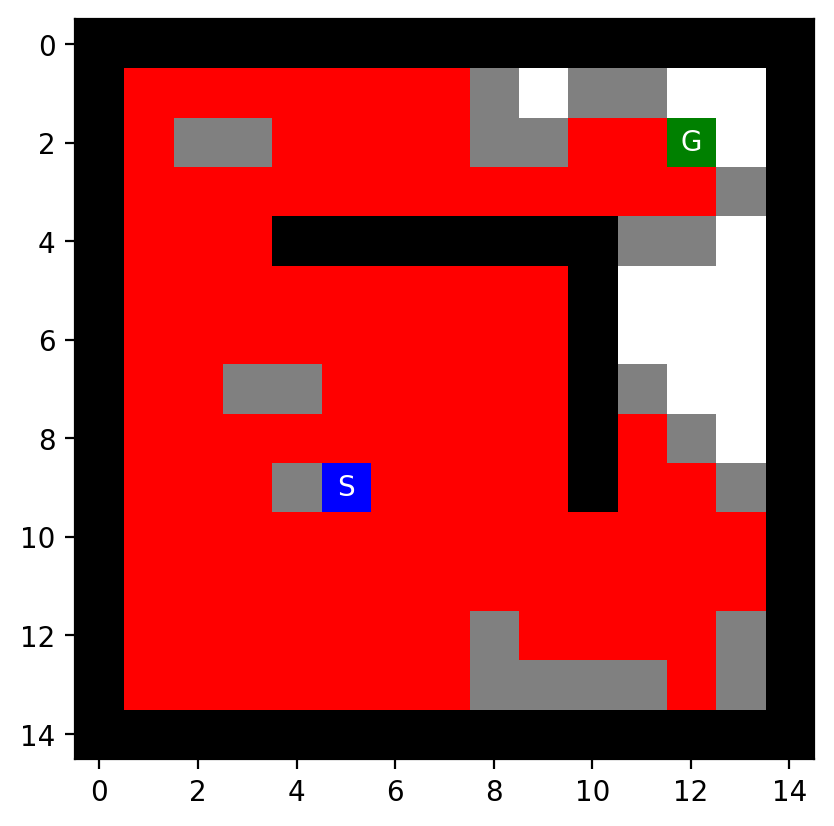

In [6]:
ts.set_order(random = True)

# run it multiple times to see the effect of randomization
for _ in range(5):
    %time result = ts.DFS(maze, check_cycle = False, max_tries = 100000, vis = False, debug_reached = True)

    #result
    ts.show_path(maze, result)
    if result['path'] is None:
        print("No solution found!")

### Run randomized DFS multiple times and use the best solution.

__Note:__ IDS takes a similar amount of time and memory, but is guaranteed optimal.

CPU times: total: 953 ms
Wall time: 2.95 s
Solutions have path_lengths of [78, 50, 70, 58, 34, 74, 58, 72, 42, 82, 92, 76, 92, 110, 44, 50, 46, 82, 34, 96, 58, 52, 56, 62, 76, 68, 28, 78, 84, 76, 92, 42, 52, 56, 62, 90, 54, 68, 78, 46, 76, 94, 46, 46, 66, 58, 38, 84, 66, 64, 64, 36, 34, 52, 90, 34, 32, 62, 64, 80, 86, 60, 94, 32, 42, 58, 64, 50, 58, 56, 80, 58, 112, 68, 104, 62, 82]
Path length: 28
Reached squares: 59
Action sequence: ['W', 'W', 'W', 'N', 'N', 'W', 'N', 'N', 'E', 'E', 'N', 'N', 'E', 'E', 'E', 'N', 'E', 'S', 'E', 'N', 'E', 'S', 'E', 'E', 'E', 'E', 'N', 'W']


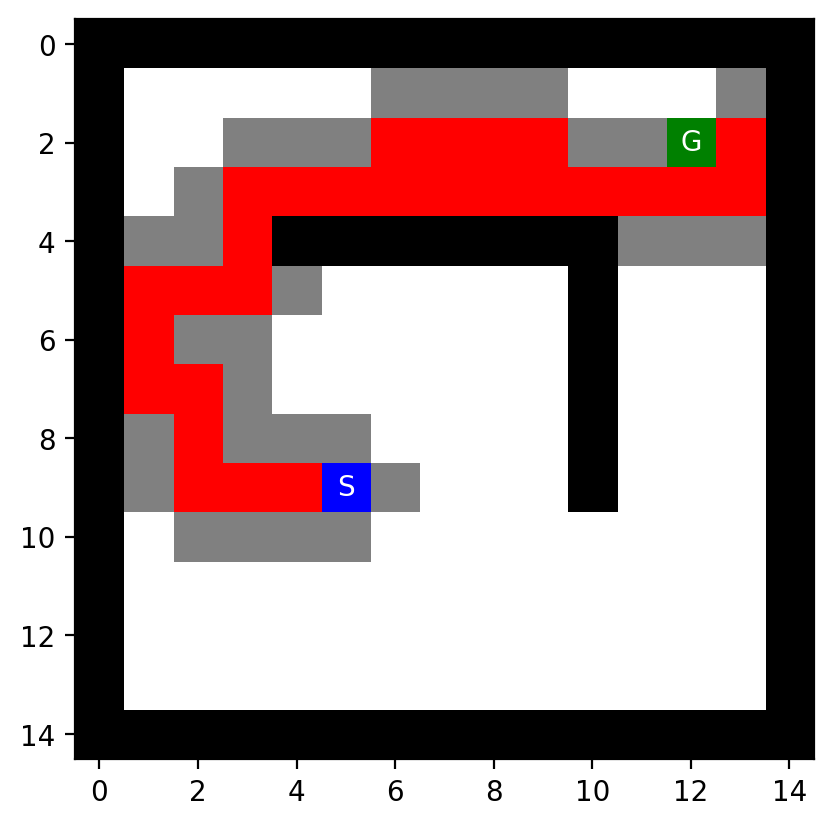

In [7]:
ts.set_order(random = True)

N = 100
%time results = [ ts.DFS(maze, max_tries = 10000, vis = False) for _ in range(N) ]

# check if we found a solution and display the best solution
results = [ r for r in results if not r['path'] is None ]
if len(results) > 0:
    path_lengths = [ len(r['path'])-1 for r in results ]

    print(f"Solutions have path_lengths of {path_lengths}")

    result = results[ts.min_index(path_lengths)]
    ts.show_path(maze, result)
else:
    print("No solution found!")

### Depth limited DFS

Note: The frontier needs to be checked differently during cycle checking!

In [8]:
ts.set_order(random = True)

%time result = ts.DFS(maze, limit = 5, frontier_option = 2, max_tries = 100000, vis = False, debug_reached = True)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 1 ms
No solution found!


### IDS

__Notes:__ 

* IDS with DFS does not store reached squares, so gray areas are not shown!

* IDS depends on the cycle checking of DFS and therefore is also affected by these problems.

CPU times: total: 0 ns


Wall time: 24.5 ms
Path length: 16
Reached squares: 151
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'E', 'N', 'N', 'N', 'N', 'N', 'N']


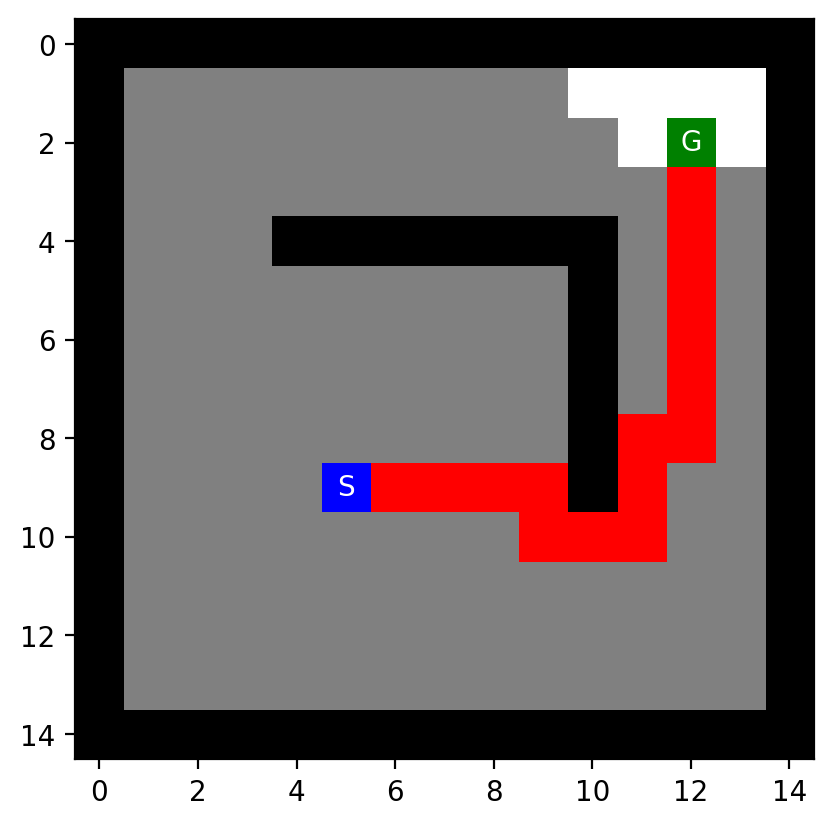

In [9]:
ts.set_order(random = True)

%time result = ts.IDS(maze, frontier_option = 2, max_tries = 100000)
ts.show_path(maze, result)

### Greedy Best-First Search (GBFS)

In [10]:
# set the heuristic to Manhattan distance
ts.heuristic = ts.manhattan

CPU times: total: 0 ns
Wall time: 1 ms
Path length: 24
Reached squares: 58
Action sequence: ['N', 'E', 'N', 'N', 'E', 'N', 'E', 'E', 'S', 'S', 'S', 'S', 'S', 'E', 'E', 'N', 'N', 'E', 'N', 'N', 'N', 'N', 'N', 'N']


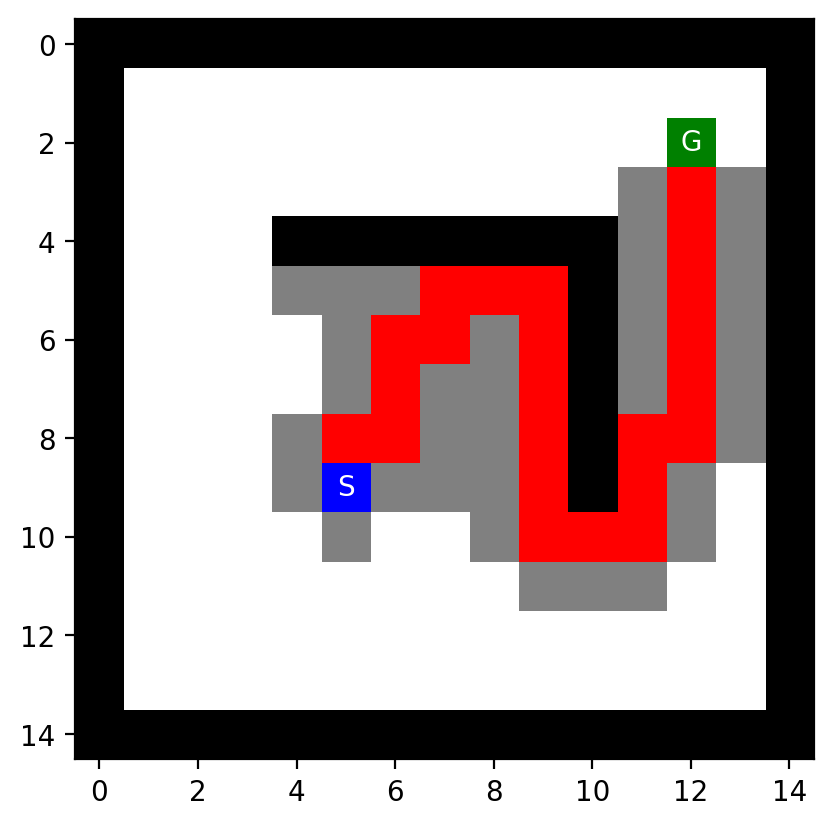

In [11]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "GBFS", debug = False, vis = False)
ts.show_path(maze, result)

### A* Search

CPU times: total: 0 ns
Wall time: 1 ms
Path length: 16
Reached squares: 63
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


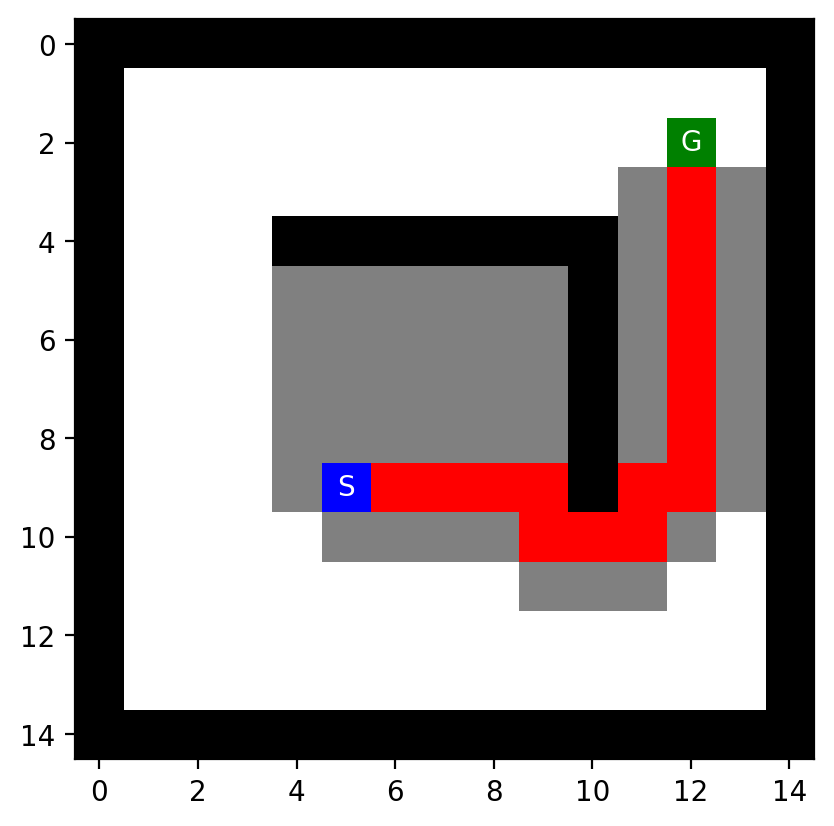

In [12]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "A*", debug = False, vis = False)
ts.show_path(maze, result)

### Weighted A* Search

$W > 1$ tends towards GBFS (optimality is not guaranteed)

CPU times: total: 0 ns
Wall time: 1.17 ms
Path length: 16
Reached squares: 66
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


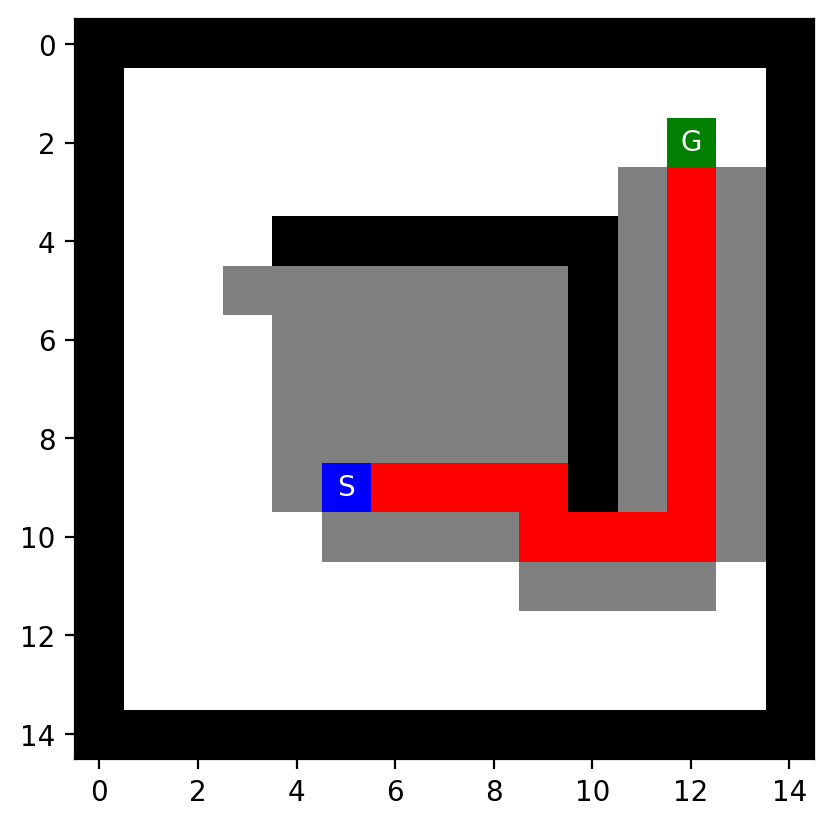

In [13]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "A*", W = 1+1e-9, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 0 ns
Path length: 18
Reached squares: 62
Action sequence: ['N', 'E', 'E', 'E', 'E', 'S', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


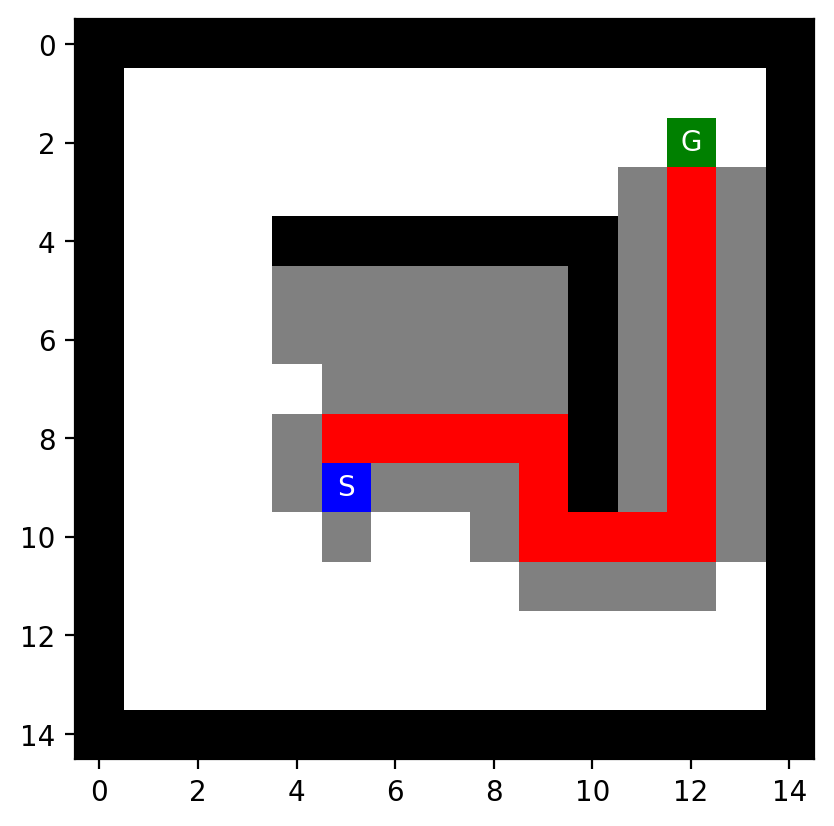

In [14]:
%time result = ts.best_first_search(maze, strategy = "A*", W = 5, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 1 ms
Path length: 16
Reached squares: 58
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'E', 'N', 'N', 'N', 'N', 'N', 'N']


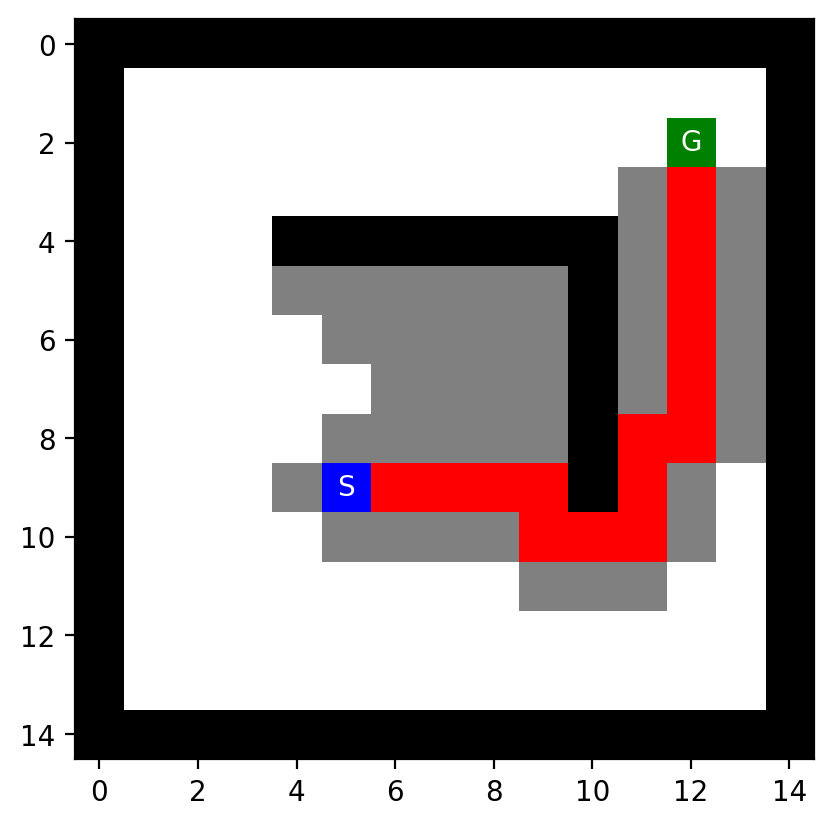

In [15]:
%time result = ts.best_first_search(maze, strategy = "A*", W = 1000, debug = False, vis = False)
ts.show_path(maze, result)

$W<1$ tends towards Uniform-Cost Search/BFS (optimality is guaranteed)

CPU times: total: 0 ns
Wall time: 2 ms
Path length: 16
Reached squares: 122
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E', 'N']


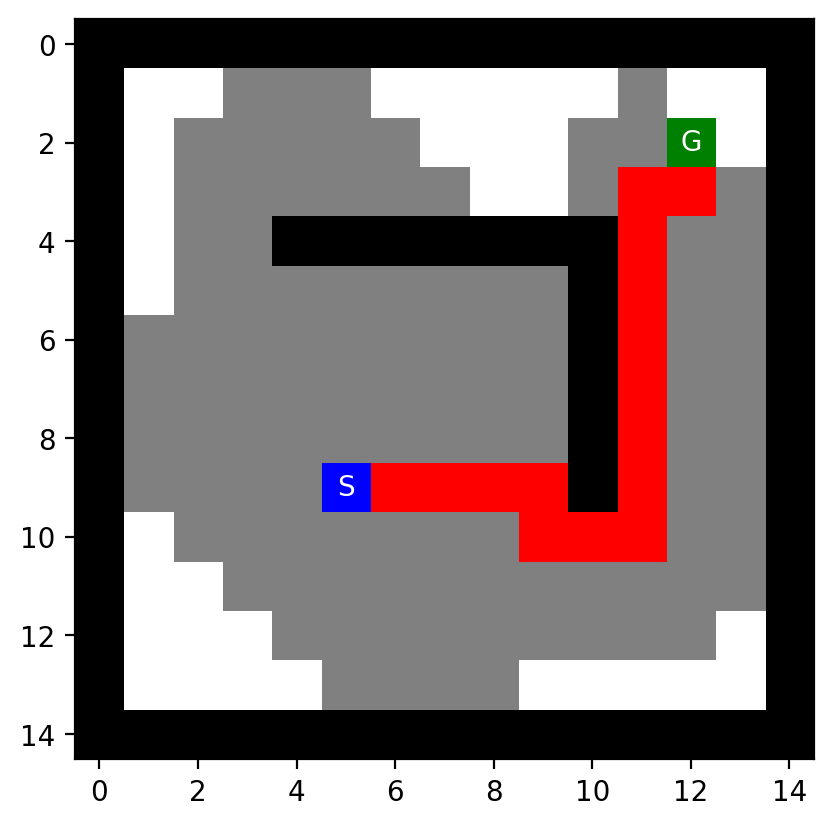

In [16]:
%time result = ts.best_first_search(maze, strategy = "A*", W = .7, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 999 μs
Path length: 16
Reached squares: 153
Action sequence: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E', 'N']


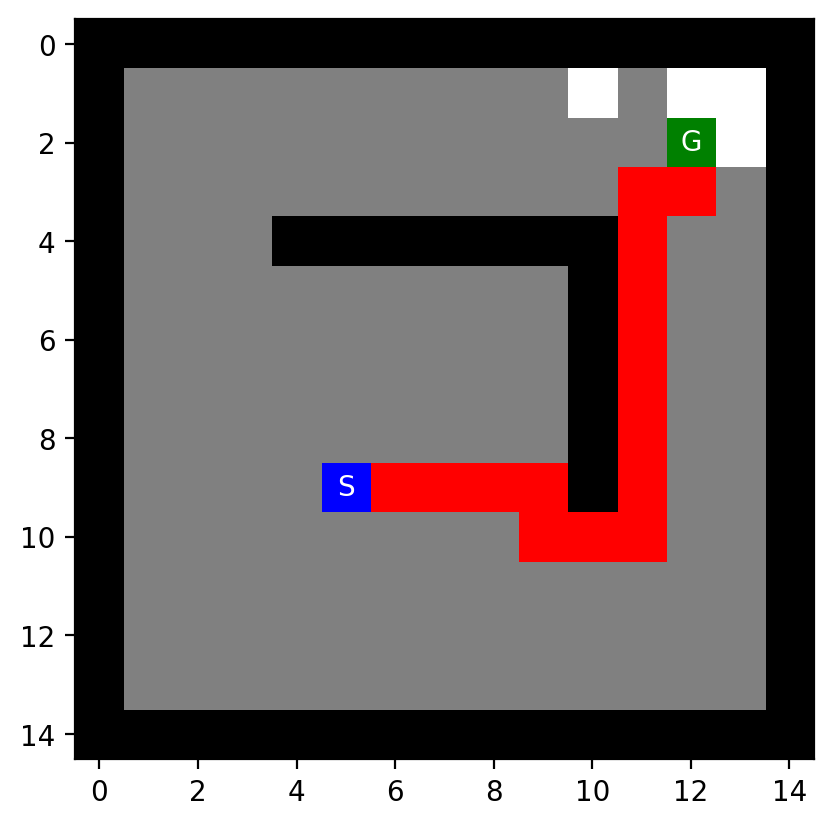

In [17]:
%time result = ts.best_first_search(maze, strategy = "A*", W = .0001, debug = False, vis = False)
ts.show_path(maze, result)

### Compare Timing

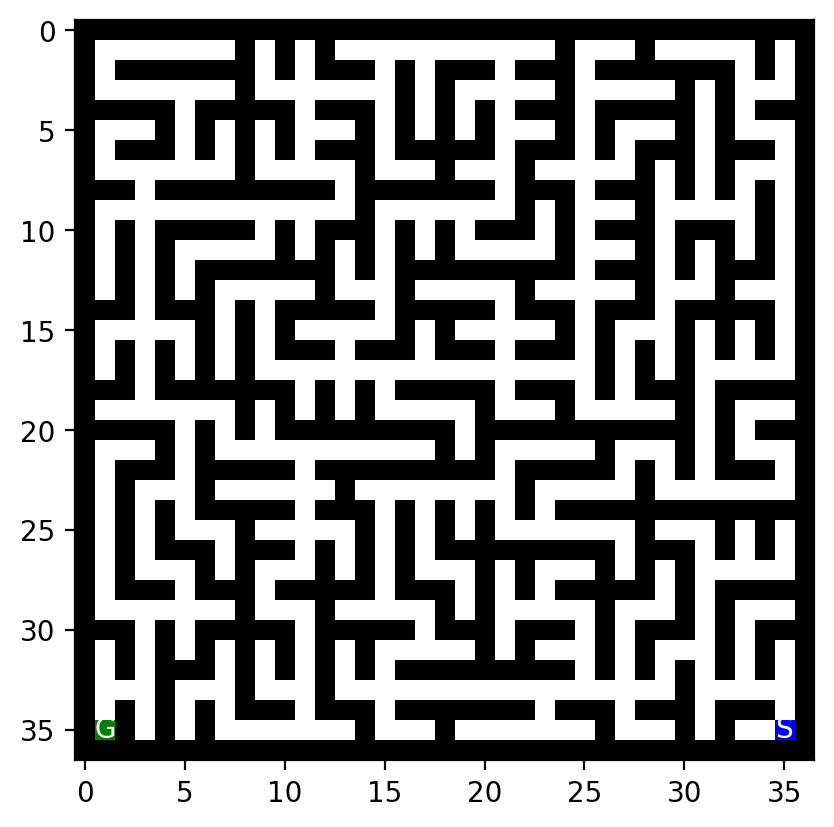

In [18]:
#f = open("small_maze.txt", "r")
#f = open("medium_maze.txt", "r")
f = open("large_maze.txt", "r")    # this has only one solution!
#f = open("open_maze.txt", "r")
#f = open("empty_maze.txt", "r")
#f = open("empty_maze_2.txt", "r")
#f = open("L_maze.txt", "r")
#f = open("loops_maze.txt", "r")

maze_str = f.read()
maze = parse_maze(maze_str)

ts.show_maze(maze)

ts.set_order(random=True)


In [19]:
import timeit
import math

reps = 10

times = {}

algorithms = ["BFS", "DFS", "GBFS", "A*"]

### FIXME: add IDS

for a in algorithms:
    times[a] = math.ceil(timeit.timeit(stmt = f'ts.best_first_search(maze, strategy = "{a}", debug = False, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)
    
times['DFS(no reached)'] = math.ceil(timeit.timeit(stmt = f'ts.DFS(maze, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)

times['IDS'] = math.ceil(timeit.timeit(stmt = f'ts.IDS(maze, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)

In [20]:
import pandas as pd
df = pd.DataFrame(times, index = ["time in micro seconds"])
df

,BFS,DFS,GBFS,A*,DFS(no reached),IDS
time in micro seconds,3372,6591,2751,3559,6638,688841


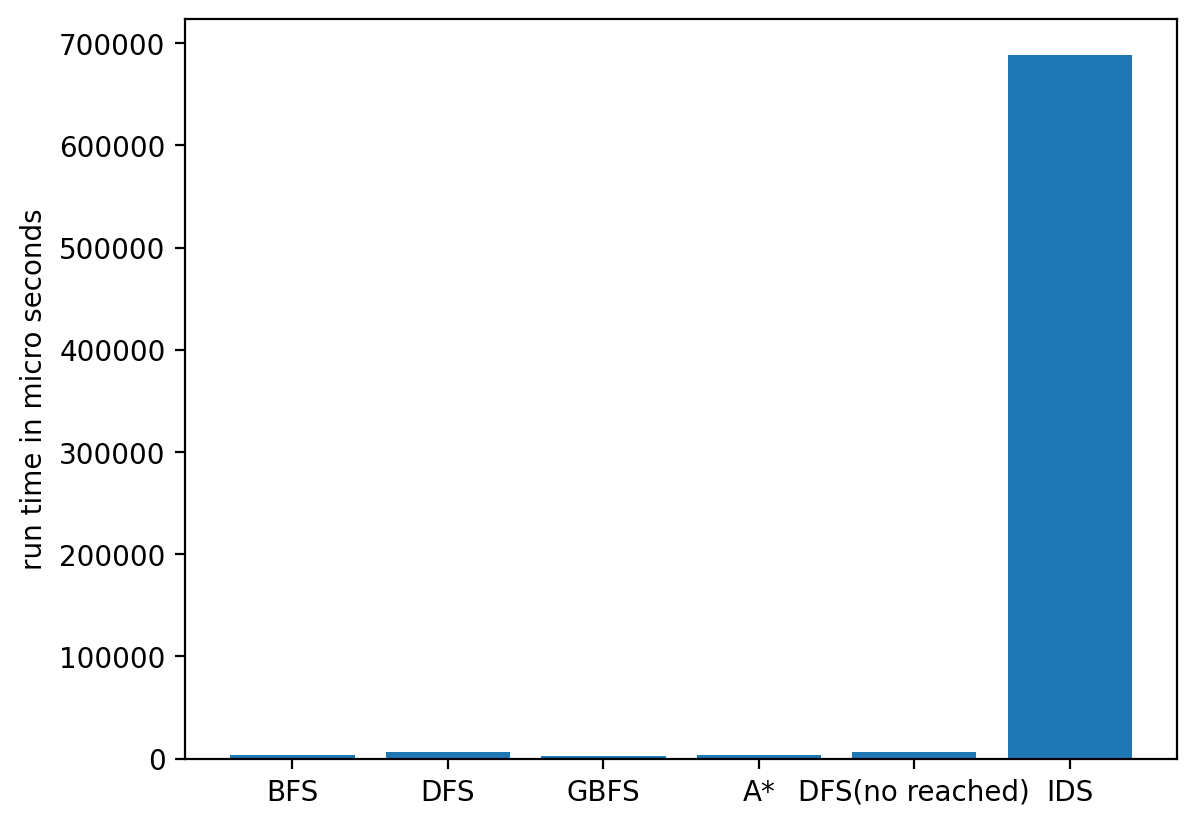

In [21]:
import matplotlib.pyplot as plt

plt.bar(df.columns, height = df.iloc[0])
plt.ylabel("run time in micro seconds")
plt.show()

# Bài 4 — Depth-Limited DFS và Iterative Deepening Search (IDS)

Phần bổ sung này giữ nguyên các ví dụ phía trên và chỉ thực hiện đúng các yêu cầu của Bài 4 trên `L_maze.txt`:

1. Khảo sát DFS khi đặt các giới hạn độ sâu khác nhau.
2. Chạy IDS và đếm số lần tăng giới hạn trước khi tìm được lời giải.
3. Giải thích quan hệ giữa DFS, DLS, IDS và ảnh hưởng của cycle checking.

> **Để kết quả tái lập được:** phần này dùng thứ tự hành động cố định `E, S, N, W` thay vì xáo trộn ngẫu nhiên. Thứ tự này có thể làm thay đổi số nút được duyệt, nhưng không làm thay đổi độ sâu nhỏ nhất mà IDS tìm thấy.

## 4.1. Ý tưởng thuật toán

**Depth-Limited DFS (DLS)** là DFS nhưng không sinh nút con khi độ sâu hiện tại bằng `limit`. Kết quả cần phân biệt:

- `FOUND`: đã gặp đích.
- `CUTOFF`: chưa thấy đích nhưng còn nhánh bị chặn bởi giới hạn; tăng giới hạn vẫn có thể tìm thấy lời giải.
- `FAILURE`: đã duyệt hết không gian hợp lệ mà không có nhánh nào bị cắt; tăng giới hạn không giúp ích.

**IDS** gọi DLS nhiều lần với `limit = 0, 1, 2, ...` và dừng ở lần đầu nhận `FOUND`. Mỗi vòng lặp mới tạo một phép tìm kiếm mới hoàn toàn.

Mê cung: L_maze.txt; S=(np.int64(9), np.int64(5)); G=(np.int64(2), np.int64(12)); thứ tự=('E', 'S', 'N', 'W')


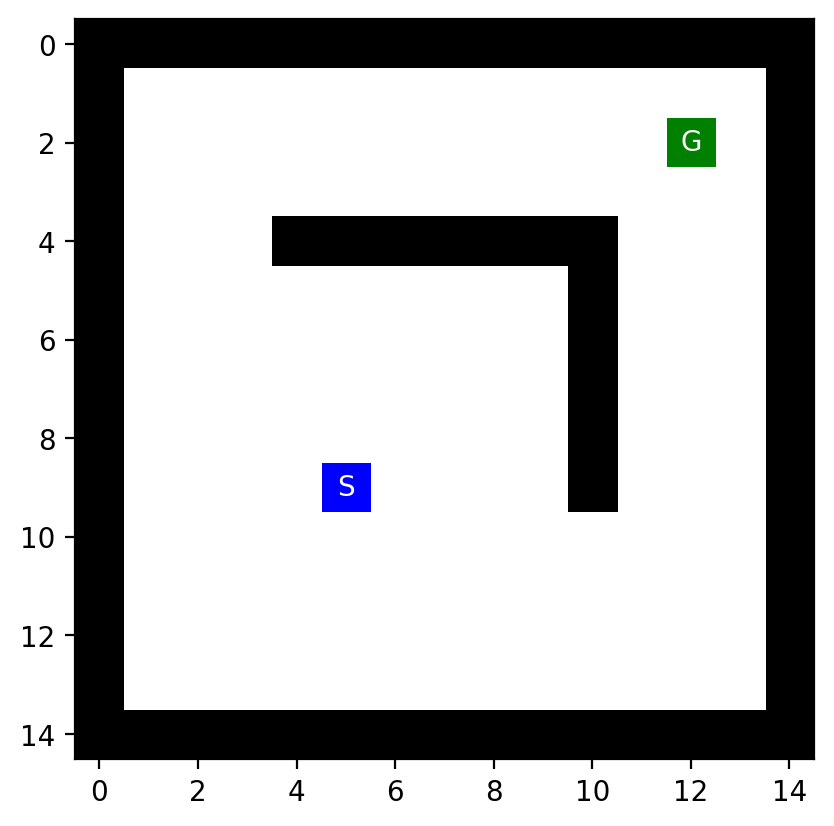

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import maze_helper as mh
from IPython.display import display

MAZE_NAME = 'L_maze.txt'
ACTION_ORDER = ('E', 'S', 'N', 'W')
MOVES = {
    'N': (-1, 0),
    'E': (0, 1),
    'S': (1, 0),
    'W': (0, -1),
}

# Chạy được cả từ thư mục lab02 lẫn thư mục gốc repository.
maze_candidates = [Path.cwd(), Path.cwd() / 'weekly assignments' / 'lab02 - Searching']
maze_dir = next((p for p in maze_candidates if (p / MAZE_NAME).exists()), None)
if maze_dir is None:
    raise FileNotFoundError(f'Không tìm thấy {MAZE_NAME}')

maze = mh.parse_maze((maze_dir / MAZE_NAME).read_text(encoding='utf-8'))
start = mh.find_pos(maze, 'S')
goal = mh.find_pos(maze, 'G')

print(f'Mê cung: {MAZE_NAME}; S={start}; G={goal}; thứ tự={ACTION_ORDER}')
mh.show_maze(maze)

In [23]:
def legal_neighbors(maze, state, order=ACTION_ORDER):
    rows, cols = maze.shape
    r, c = state
    for action in order:
        dr, dc = MOVES[action]
        child = (r + dr, c + dc)
        if (0 <= child[0] < rows and 0 <= child[1] < cols
                and maze[child] != 'X'):
            yield action, child


def depth_limited_dfs(maze, start, goal, limit, order=ACTION_ORDER):
    """DFS giới hạn độ sâu, cycle checking chỉ trên đường đi hiện tại."""
    path = [start]
    actions = []
    on_path = {start}
    stats = {'visited': 0, 'expanded': 0, 'cutoff_occurred': False}

    def visit(state, depth):
        stats['visited'] += 1
        if state == goal:
            return True

        # Chỉ chặn tổ tiên của state; không dùng reached toàn cục.
        children = [
            (action, child)
            for action, child in legal_neighbors(maze, state, order)
            if child not in on_path
        ]

        if depth == limit:
            if children:
                stats['cutoff_occurred'] = True
            return False

        stats['expanded'] += 1
        for action, child in children:
            on_path.add(child)
            path.append(child)
            actions.append(action)

            if visit(child, depth + 1):
                return True

            actions.pop()
            path.pop()
            on_path.remove(child)

        return False

    found = visit(start, 0)
    status = 'FOUND' if found else ('CUTOFF' if stats['cutoff_occurred'] else 'FAILURE')
    return {
        'limit': limit,
        'status': status,
        'path': path.copy() if found else None,
        'actions': actions.copy() if found else None,
        'path_cost': len(actions) if found else None,
        'visited': stats['visited'],
        'expanded': stats['expanded'],
    }


def iterative_deepening_search(maze, start, goal, max_limit=100, order=ACTION_ORDER):
    history = []
    for limit in range(max_limit + 1):
        result = depth_limited_dfs(maze, start, goal, limit, order)
        history.append(result)

        if result['status'] == 'FOUND':
            result['history'] = history
            result['dls_calls'] = len(history)
            result['limit_increases'] = limit  # bắt đầu từ limit = 0
            return result

        if result['status'] == 'FAILURE':
            break

    return {
        'status': 'FAILURE', 'path': None, 'actions': None,
        'history': history, 'dls_calls': len(history),
        'limit_increases': max(0, len(history) - 1),
    }

## 4.2. Khảo sát Depth-Limited DFS

Ta thử các giới hạn 5, 10, 15 và 16. Nếu lời giải nông nhất có độ sâu 16 thì mọi giới hạn nhỏ hơn 16 phải trả về `CUTOFF`; tại 16 thuật toán mới có thể trả về `FOUND`.

In [24]:
dls_trials = [depth_limited_dfs(maze, start, goal, limit) for limit in (5, 10, 15, 16)]
dls_table = pd.DataFrame([
    {
        'giới hạn': result['limit'],
        'trạng thái': result['status'],
        'nút được xét': result['visited'],
        'nút mở rộng': result['expanded'],
        'chi phí lời giải': result['path_cost'],
    }
    for result in dls_trials
])
display(dls_table.style.hide(axis='index').set_caption('DLS với các giới hạn độ sâu khác nhau'))

giới hạn,trạng thái,nút được xét,nút mở rộng,chi phí lời giải
5,CUTOFF,433,153,nan
10,CUTOFF,41161,17687,nan
15,CUTOFF,2455735,1098859,nan
16,FOUND,945,475,16.000000


## 4.3. Chạy IDS và ghi lại số lần tăng giới hạn

Quy ước rõ ràng: IDS bắt đầu với `limit = 0`. Vì vậy, nếu tìm thấy ở giới hạn 16 thì có **17 lần gọi DLS** và **16 lần tăng giới hạn**: $0\rightarrow1, 1\rightarrow2, ..., 15\rightarrow16$.

In [25]:
ids_result = iterative_deepening_search(maze, start, goal, max_limit=30)
history_table = pd.DataFrame([
    {
        'giới hạn': result['limit'],
        'trạng thái': result['status'],
        'nút được xét': result['visited'],
        'nút mở rộng': result['expanded'],
        'chi phí lời giải': result['path_cost'],
    }
    for result in ids_result['history']
])

print(f"Trạng thái cuối: {ids_result['status']}")
print(f"Giới hạn tìm thấy lời giải: {ids_result['limit']}")
print(f"Số lần gọi DLS: {ids_result['dls_calls']}")
print(f"Số lần tăng giới hạn: {ids_result['limit_increases']}")
print(f"Chi phí/độ sâu lời giải: {ids_result['path_cost']}")
print(f"Chuỗi hành động: {''.join(ids_result['actions'])}")
display(history_table.style.hide(axis='index').set_caption('Lịch sử các vòng lặp của IDS'))

# Kiểm tra các kết quả cốt lõi của bài.
assert ids_result['status'] == 'FOUND'
assert ids_result['limit'] == ids_result['path_cost'] == 16
assert ids_result['dls_calls'] == 17
assert ids_result['limit_increases'] == 16

Trạng thái cuối: FOUND
Giới hạn tìm thấy lời giải: 16
Số lần gọi DLS: 17
Số lần tăng giới hạn: 16
Chi phí/độ sâu lời giải: 16
Chuỗi hành động: EEEESEEENNNNNNNN


giới hạn,trạng thái,nút được xét,nút mở rộng,chi phí lời giải
0,CUTOFF,1,0,nan
1,CUTOFF,5,1,nan
2,CUTOFF,17,5,nan
3,CUTOFF,53,17,nan
4,CUTOFF,153,53,nan
5,CUTOFF,433,153,nan
6,CUTOFF,1166,433,nan
7,CUTOFF,3022,1166,nan
8,CUTOFF,7424,3022,nan
9,CUTOFF,17687,7424,nan


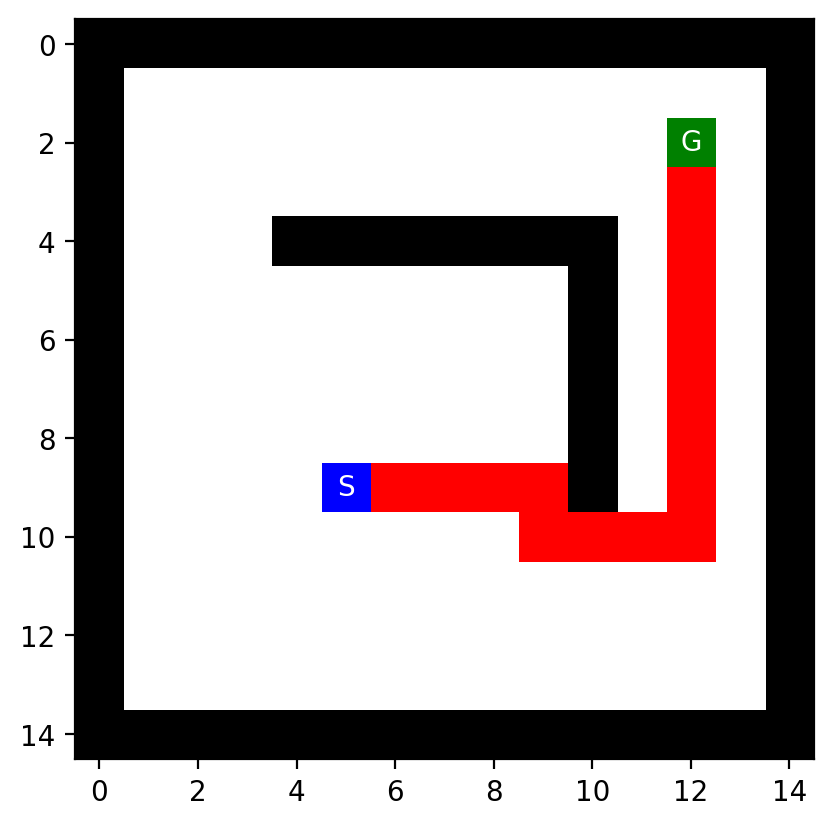

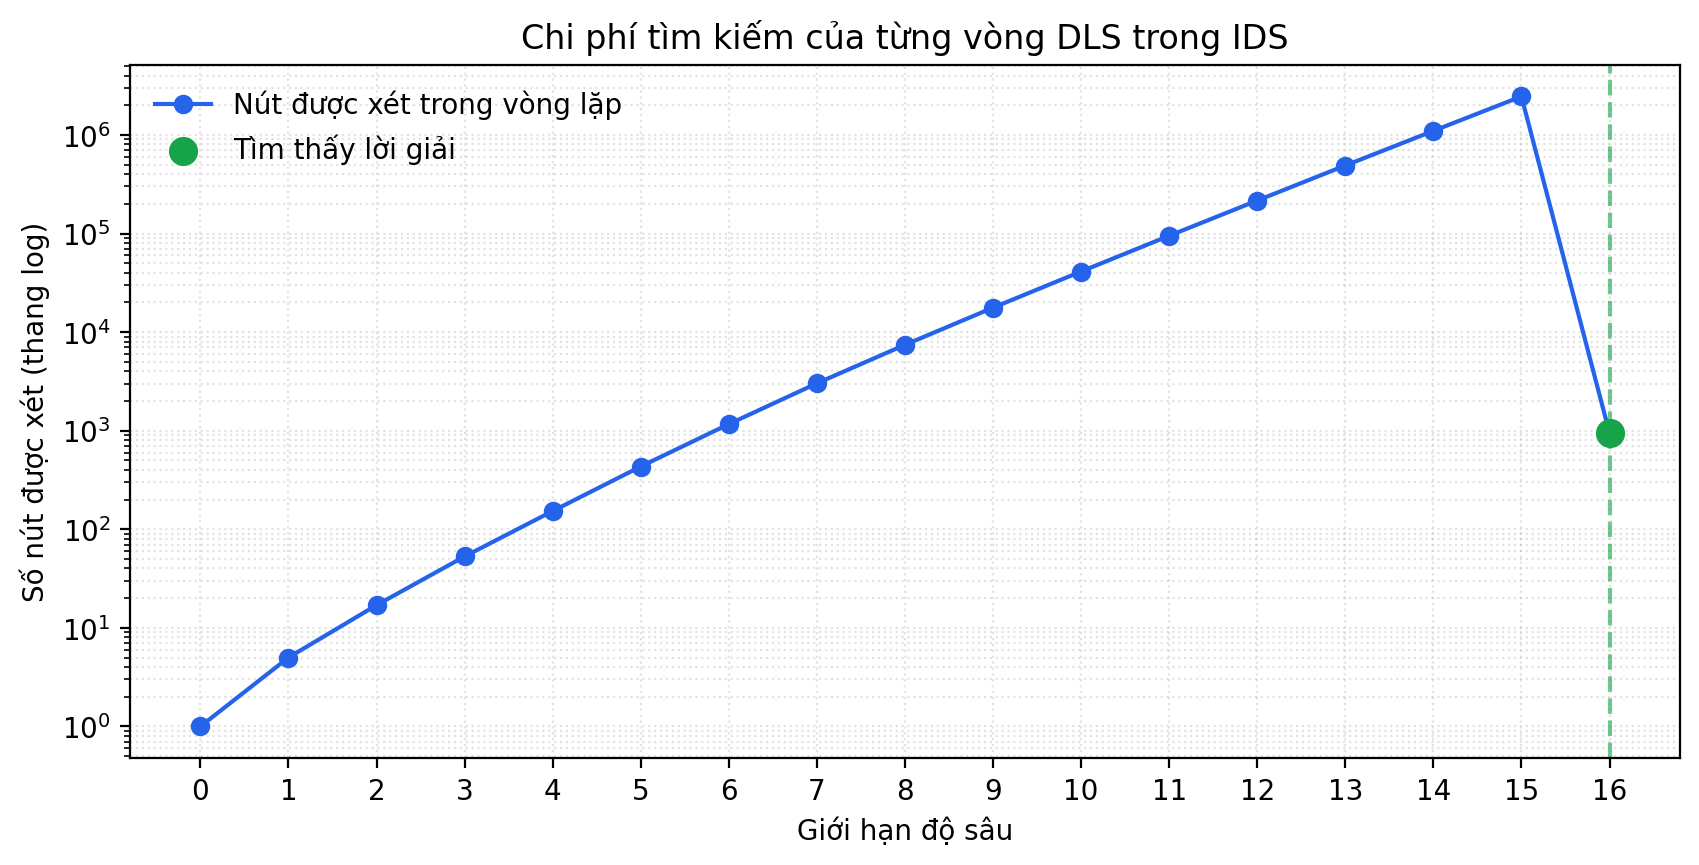

In [26]:
# Đánh dấu lời giải cuối cùng bằng P và hiển thị trên mê cung.
solved_maze = maze.copy()
for state in ids_result['path'][1:-1]:
    solved_maze[state] = 'P'
mh.show_maze(solved_maze)

# Dùng thang log vì số nhánh đường đi tăng rất nhanh theo giới hạn.
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(history_table['giới hạn'], history_table['nút được xét'],
        marker='o', color='#2563eb', label='Nút được xét trong vòng lặp')
found_row = history_table.iloc[-1]
ax.scatter(found_row['giới hạn'], found_row['nút được xét'],
           color='#16a34a', s=90, zorder=3, label='Tìm thấy lời giải')
ax.axvline(ids_result['limit'], color='#16a34a', linestyle='--', alpha=0.6)
ax.set_yscale('log')
ax.set_xticks(history_table['giới hạn'])
ax.set_xlabel('Giới hạn độ sâu')
ax.set_ylabel('Số nút được xét (thang log)')
ax.set_title('Chi phí tìm kiếm của từng vòng DLS trong IDS')
ax.grid(True, which='both', linestyle=':', alpha=0.35)
ax.legend(frameon=False)
plt.show()

## 4.4. Phân tích kết quả

### Vì sao IDS kết hợp ưu điểm của BFS và DFS?

- Giống **DFS**, mỗi lần DLS chỉ giữ đường đi hiện tại và một lượng nhỏ thông tin cho các nhánh chưa xét. Bộ nhớ là $O(bd)$, nhỏ hơn bộ nhớ $O(b^d)$ của BFS.
- Giống **BFS**, IDS hoàn tất toàn bộ các độ sâu nhỏ hơn trước khi thử độ sâu lớn hơn. Lần đầu tìm thấy đích vì thế nằm ở độ sâu nhỏ nhất. Với chi phí mỗi bước bằng 1, lời giải đó là tối ưu.
- IDS phải duyệt lại các nút nông qua nhiều vòng, nhưng trong cây tìm kiếm có hệ số phân nhánh $b>1$, phần lớn nút nằm ở tầng sâu nhất. Do đó chi phí lặp lại thường chấp nhận được; độ phức tạp thời gian vẫn là $O(b^d)$.

### Kết quả trên `L_maze`

- Các giới hạn 5, 10 và 15 đều cho `CUTOFF`, không phải `FAILURE`: vẫn còn nhánh có thể đi sâu hơn.
- IDS tìm thấy lời giải dài 16 bước tại `limit = 16`. Theo quy ước bắt đầu từ 0, thuật toán gọi DLS 17 lần và tăng giới hạn 16 lần.
- Số nút được xét tăng nhanh vì vùng trống cho phép nhiều đường đi đơn khác nhau. Thứ tự hành động ảnh hưởng đáng kể đến số nút xét ở vòng cuối, nhưng không thay đổi giới hạn đầu tiên có lời giải.

### Cycle checking ảnh hưởng IDS như thế nào?

| Cách kiểm tra | Ảnh hưởng |
|---|---|
| Không kiểm tra | DLS vẫn kết thúc nhờ giới hạn, nhưng lãng phí rất nhiều lần đi tới–đi lui. |
| Kiểm tra trên đường hiện tại (`on_path`) | Loại chu trình quay lại tổ tiên, giữ đặc tính bộ nhớ thấp của DFS và vẫn cho phép cùng trạng thái được đi tới từ một nhánh khác. Đây là cách dùng trong phần cài đặt trên. |
| `reached` toàn cục dùng chung giữa các vòng IDS | **Không phù hợp**: trạng thái đã thấy ở giới hạn nhỏ sẽ bị chặn ở giới hạn lớn, nên IDS có thể bỏ lỡ lời giải. Mỗi vòng phải khởi tạo lại dữ liệu kiểm tra. |
| `reached` toàn cục đơn giản trong một vòng DLS | Có thể sai nếu một trạng thái được gặp lần đầu bằng đường sâu, rồi đường nông hơn tới cùng trạng thái bị loại. Nếu muốn dùng, phải lưu độ sâu tốt nhất và mở lại trạng thái khi tìm được đường nông hơn. |

**Kết luận:** IDS đầy đủ và tối ưu cho mê cung hữu hạn với hệ số phân nhánh hữu hạn, chi phí mỗi bước bằng nhau và cycle checking đúng. Cài đặt cycle checking không phù hợp có thể làm thay đổi số nút duyệt, làm chậm đáng kể, hoặc nghiêm trọng hơn là khiến thuật toán bỏ sót lời giải.